## Question: "When do I observe my target to minimise the background?"

### [JWST Backgrounds Tool](https://jwst-docs.stsci.edu/jwst-other-tools/jwst-backgrounds-tool#gsc.tab=0)

100%|██████████| 183/183 [01:30<00:00,  2.02it/s]

Days with background below 1.2x min: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44 249 250 251 252 253 254 255 256 257
 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275
 276 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 293
 294 295 296 297 298 299 300 301 302 303 304 305 306 307 308 309 310 311
 312 313 314 315 329 330 331 332 333 334 335 336 337 338 339 340 341 342
 343 344 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360
 361 362 363 364 365]


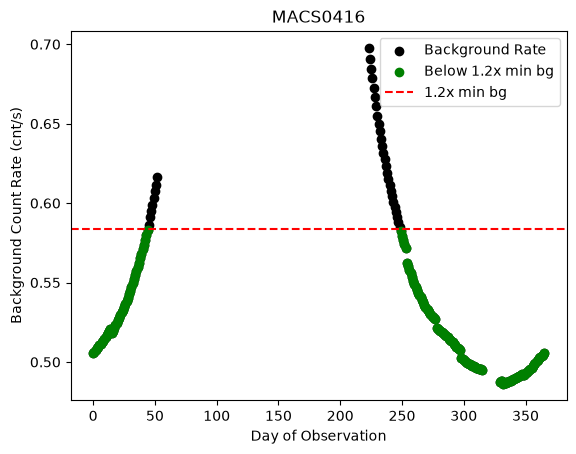

In [1]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "./data/pandeia_data-2026.2-jwst"
os.environ["PSF_DIR"] = "./data/pandeia_psfs-2026.2-jwst"
os.environ["PYSYN_CDBS"] = "./data/grp/redcat/trds"

from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation
import matplotlib.pyplot as plt
from jwst_backgrounds import jbt
import numpy as np
from tqdm import tqdm

# The following are parameters which can easily be changed
telescope = 'jwst'
instrument = 'nircam'
mode = 'lw_imaging'
filter = 'f356w'
 
# Source parameters
offsets = {'x': 0., 'y': 0.}
geometry = 'point'
sed = 'comp_qso'
key = 'qso'
bandpass = f'{instrument},{mode},{filter}'
magnitude = 26
threshold = 1.2

# Background parameters
name = 'MACS0416'
ra, dec = 64.038, -24.073 # Target
wavelength_um = 3
bg = jbt.background(ra, dec, wavelength_um, thresh=threshold)
observability_calendar = bg.bkg_data['calendar']
# jbt.get_background(ra, dec, wavelength_um, thresh=threshold) # faster but not as accurate
 
scene_dictionary = {}
scene_dictionary['position'] = {'position_parameters': ['x_offset', 'y_offset']}
scene_dictionary['position']['x_offset'] = offsets['x']
scene_dictionary['position']['y_offset'] = offsets['y']
scene_dictionary['shape'] = {'geometry': 'point'}
scene_dictionary['spectrum'] = {'name': name, 'spectrum_parameters': ['sed', 'normalization']}
scene_dictionary['spectrum']['sed'] = {'sed_type': sed, 'key': key}
scene_dictionary['spectrum']['normalization'] = {'type': 'jwst', 'norm_fluxunit': 'abmag'}
scene_dictionary['spectrum']['normalization']['bandpass'] = bandpass
scene_dictionary['spectrum']['normalization']['norm_flux'] = magnitude
scene_dictionary['spectrum']['lines'] = []
scene_dictionary['spectrum']['extinction'] = {'bandpass': 'j', 'law': 'mw_rv_31', 'unit': 'mag', 'value': 0}

# Create lists to hold the results
dates, fluxes = [], []

# Loop over each day in the observability calendar and perform the calculation
for i, day in enumerate(tqdm(observability_calendar)):
    configuration_dictionary = build_default_calc(telescope, instrument, mode)
    configuration_dictionary['scene'][0] = scene_dictionary
    configuration_dictionary['configuration']['instrument']['filter'] = filter

    # Set the background for this day
    flux_array = bg.bkg_data['total_bg'][i]
    configuration_dictionary['background'] = [bg.bkg_data['wave_array'], flux_array]

    # Perform the calculation
    report_object = perform_calculation(configuration_dictionary, dict_report=False)
    background_rate = np.median(report_object.bg_pix) # median per-pixel background count rate
    dates.append(day)
    fluxes.append(background_rate)

# Analyze results
min_mask = np.array(fluxes) < 1.2 * min(fluxes)
dates_below = np.array(dates)[min_mask]
flux_below = np.array(fluxes)[min_mask]
print(f"Days with background below {threshold}x min:", dates_below)

# Plot results
plt.scatter(dates, fluxes, label='Background Rate', color='black')
plt.scatter(dates_below, flux_below, color='green', label=f'Below {threshold}x min bg')
plt.axhline(threshold*min(fluxes), color='red', ls='--', label=f'{threshold}x min bg')
plt.title(name)
plt.xlabel("Day of Observation")
plt.ylabel("Background Count Rate (cnt/s)")
plt.legend()
plt.savefig(f"{name}_background_rate_vs_day.png")
plt.show()

## Question: "For the low-background observing windows, what roll angles are available on those dates?"

### Using [JWST GTVT](https://jwst-docs.stsci.edu/jwst-other-tools/jwst-target-visibility-tools/jwst-general-target-visibility-tool-help#gsc.tab=0):

### Also Refer to [JWST Position Angles, Ranges, and Offsets](https://jwst-docs.stsci.edu/jwst-observatory-characteristics-and-performance/jwst-position-angles-ranges-and-offsets#gsc.tab=0)


In [2]:
# Parameters 
year = 2026
split_threshold = 40 # days gap to define separate windows

# Compute consecutive differences
dx = np.diff(dates_below)
break_idx = np.where(dx > split_threshold)[0][0] + 1 # index *after* the break

# Split arrays
window1, window2 = np.split(dates_below, [break_idx])

# Convert day-of-year (1-365/366) for a given year to 'YYYY-MM-DD'.
from datetime import date, timedelta
def doy_to_ymd(year, day_of_year):
    d = date(year, 1, 1) + timedelta(days=day_of_year - 1)
    return d.strftime("%Y-%m-%d")

# Get start and end dates for both windows
start_first_window = doy_to_ymd(year, float(window1[1]))
end_first_window = doy_to_ymd(year, float(window1[-1]))
start_second_window = doy_to_ymd(year, float(window2[0]))
end_second_window = doy_to_ymd(year, float(window2[-1]))

print(f'First window: {start_first_window} to {end_first_window}')
print(f'Second window: {start_second_window} to {end_second_window}')

# jwst_gtvt calls. Must be installed in your environment.
!jwst_gtvt --ra={ra} --dec={dec} --instrument v3pa --write_plot {name}_v3pa_1st_window.png --start_date {start_first_window} --end_date {end_first_window}
!jwst_gtvt --ra={ra} --dec={dec} --instrument v3pa --write_plot {name}_v3pa_2nd_window.png --start_date {start_second_window} --end_date {end_second_window}

First window: 2026-01-01 to 2026-02-13
Second window: 2026-09-06 to 2026-12-31
+------------------------------------------+
| JWST General Target Visibility Tool      |
+------------------------------------------+
| Runtime/Date: 2026-07-15 16:09:32.741753 |
+------------------------------------------+
| Version Number: 1.2                      |
+------------------------------------------+
RA: 64.038      Dec: -24.073     Ecliptic Latitude: -44.48894391567812
----------------------------------------------------------------------

Checked Interval [2026-01-01 00:00:00.000, 2026-02-13 00:00:00.000]

+----------------+--------------+-------------------+------------------+----------------+
| Window Start   | Window End   |   Window Duration |   V3 Angle Start |   V3 Angle End |
|----------------+--------------+-------------------+------------------+----------------|
| 2026-01-02     | 2026-02-13   |                42 |          40.1197 |        73.5478 |
+----------------+--------------+-